 ### 1. Import libraries

**Mục đích:** Nạp các thư viện cần thiết để xử lý dữ liệu, thực hiện lựa chọn đặc trưng bằng RFECV và giảm chiều dữ liệu (PCA, SVD, LDA).  
**Input:** Thư viện hệ thống `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`.  
**Output:** Môi trường lập trình sẵn sàng cho các bước xử lý và mô hình hóa.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo đỏ để notebook sạch đẹp

# Thư viện cho Feature Selection (Chỉ dùng RFECV)
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

# Thư viện cho Dimensionality Reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

### 2. Read and prepare dataset

**Mục đích:** Đọc dữ liệu, loại bỏ cột định dạng chuỗi (`date`), tách biến mục tiêu và chuẩn hóa tập đặc trưng về cùng thang đo (bắt buộc trước khi giảm chiều). Đồng thời rời rạc hóa (discretize) biến mục tiêu thành 3 nhóm để dùng riêng cho LDA.  
**Input:** File CSV `KAG_energydata_complete.csv`.  
**Output:** Tập đặc trưng đã chuẩn hóa `X_scaled`, biến mục tiêu liên tục `y_continuous` và biến phân loại `y_categorical`.

In [6]:
# Tải dữ liệu
df = pd.read_csv('KAG_cleaned_week1.csv')

# Bỏ cột 'date' vì thuật toán không đọc được dạng chuỗi
# Bỏ cột 'Appliances' để tạo tập đặc trưng X
X = df.drop(columns=['date', 'Appliances'])

# Biến mục tiêu liên tục cho RFECV
y_continuous = df['Appliances']

# Biến mục tiêu phân loại (3 nhóm) dành riêng cho LDA
y_categorical = pd.qcut(y_continuous, q=3, labels=[0, 1, 2])

# Chuẩn hóa X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Kích thước X ban đầu:", X_scaled.shape)

Kích thước X ban đầu: (19735, 32)


### 3. Feature Selection using RFECV

**Mục đích:** Tìm ra tập hợp các đặc trưng tối ưu nhất bằng cách huấn luyện mô hình Random Forest, đánh giá qua Cross-Validation và loại bỏ đệ quy các biến yếu nhất.  
**Input:** Tập đặc trưng `X_scaled` và biến mục tiêu `y_continuous`.  
**Output:** Tập dữ liệu rút gọn `X_rfecv_selected` chỉ giữ lại những đặc trưng mang nhiều thông tin dự báo nhất.

In [7]:
# Khởi tạo mô hình Random Forest làm lõi đánh giá
estimator = RandomForestRegressor(n_estimators=10, random_state=42)

# Khởi tạo RFECV: Loại từng biến một (step=1), chia 3 tập kiểm chứng (cv=3)
selector_rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=KFold(3),
    min_features_to_select=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Chạy thuật toán tìm biến
selector_rfecv.fit(X_scaled, y_continuous)

# Lọc lại tập X chỉ chứa các biến tốt nhất
X_rfecv_selected = selector_rfecv.transform(X_scaled)

print(f"Số lượng đặc trưng tối ưu được giữ lại: {selector_rfecv.n_features_} / {X_scaled.shape[1]}")

Số lượng đặc trưng tối ưu được giữ lại: 2 / 32


### 4. Dimensionality Reduction (PCA, SVD, LDA)

**Mục đích:** Nén tập dữ liệu đã qua chọn lọc (Feature Selection) xuống còn 2 chiều không gian (2 components) để trực quan hóa, đồng thời so sánh sự khác biệt giữa các thuật toán có giám sát (LDA) và không giám sát (PCA, SVD).  
**Input:** Tập dữ liệu `X_rfecv_selected` và nhãn phân loại `y_categorical` (dành riêng cho LDA).  
**Output:** Các ma trận dữ liệu 2 chiều `X_pca`, `X_svd`, `X_lda`.

In [8]:
# CHÚ Ý: Ta sẽ áp dụng giảm chiều trên tập dữ liệu đã được RFECV lọc ra để mô hình nhẹ và tinh.
# Nếu bạn muốn giảm chiều trên dữ liệu gốc, hãy thay 'X_rfecv_selected' bằng 'X_scaled'

# 1. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_rfecv_selected)

# 2. SVD
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X_rfecv_selected)

# 3. LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_rfecv_selected, y_categorical)

print("Đã hoàn thành giảm dữ liệu xuống 2 chiều cho cả PCA, SVD và LDA.")

Đã hoàn thành giảm dữ liệu xuống 2 chiều cho cả PCA, SVD và LDA.


### 5. Visualize Reduced Data

**Mục đích:** Trực quan hóa dữ liệu sau khi giảm chiều bằng biểu đồ phân tán (Scatter plot) để đánh giá khả năng phân tách các mức độ tiêu thụ năng lượng (Low, Medium, High).  
**Input:** Các tập dữ liệu 2 chiều (`X_pca`, `X_svd`, `X_lda`) và nhãn phân loại `y_categorical`.  
**Output:** 3 biểu đồ thể hiện không gian phân bổ dữ liệu của từng thuật toán.

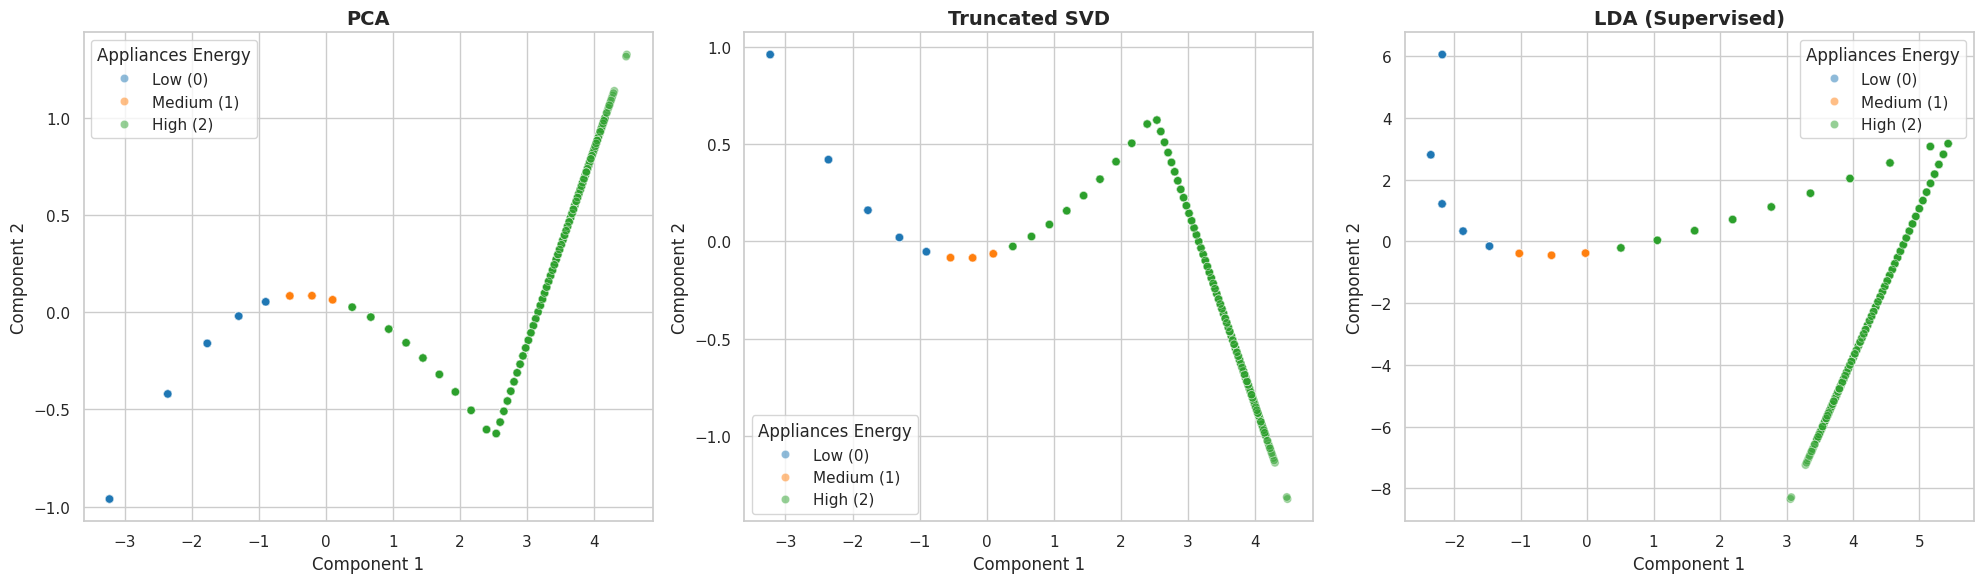

In [9]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def plot_2d_space(X_reduced, y, title, ax):
    sns.scatterplot(
        x=X_reduced[:, 0],
        y=X_reduced[:, 1],
        hue=y,
        palette=['#1f77b4', '#ff7f0e', '#2ca02c'],
        alpha=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Low (0)', 'Medium (1)', 'High (2)'], title="Appliances Energy")

# Gọi hàm vẽ 3 biểu đồ tương ứng
plot_2d_space(X_pca, y_categorical, 'PCA', axes[0])
plot_2d_space(X_svd, y_categorical, 'Truncated SVD', axes[1])
plot_2d_space(X_lda, y_categorical, 'LDA (Supervised)', axes[2])

plt.tight_layout()
plt.show()

### 6. Kết luận:

- **Feature Selection (RFECV):** Thuật toán RFECV đã tinh lọc tập dữ liệu ban đầu xuống còn các đặc trưng quan trọng nhất giúp tối ưu hóa mô hình và giảm bớt nhiễu.
- **Dimensionality Reduction (PCA, SVD, LDA):**
   - **PCA & SVD** bảo toàn cấu trúc phân bố tự nhiên của dữ liệu, cho thấy sự tăng dần liên tục từ mức tiêu thụ năng lượng Thấp (Low) đến Cao (High).
   - **LDA** tận dụng thông tin nhãn phân loại nên cho khả năng phân tách nhóm tiêu thụ năng lượng Cao (High) rõ rệt hơn trong không gian 2 chiều.